# Autoencoder Confusion Matrices from CSV Outputs

This notebook reads the debug CSV files saved in `tmp/`, draws one overall confusion matrix for each experiment, and when available also draws confusion matrices for each `original_category` subset stored in the CSV.


### PARAMETERS:


In [1]:
from pathlib import Path

tmp_dir = Path("tmp")
ncols = 3
normalize = None
category_ncols = 3
show_category_breakdown = True
save_figure = False
figure_path = tmp_dir / "ae_confusion_matrices.png"


In [2]:
from itertools import combinations
import math

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

FEATURE_GROUPS = {
    "FLOW": ["bs", "ps", "br", "pr", "td"],
    "CTLS": ["tls.cver", "tls.ccs", "tls.cext", "tls.csg", "tls.alpn", "tls.csv"],
    "STLS": ["tls.sver", "tls.scs", "tls.sext", "tls.ssv"],
    "REC": ["tls.rec"],
}

FEATURE_SET_LOOKUP = {("full",): "FULL"}
group_names = list(FEATURE_GROUPS)
for size in range(1, len(group_names) + 1):
    for group_combo in combinations(group_names, size):
        feature_tokens = []
        for group_name in group_combo:
            feature_tokens.extend(FEATURE_GROUPS[group_name])
        FEATURE_SET_LOOKUP[tuple(feature_tokens)] = " + ".join(group_combo)

def format_feature_set(feature_key: str) -> str:
    tokens = tuple(feature_key.split("_"))
    return FEATURE_SET_LOOKUP.get(tokens, feature_key.replace("_", ", "))

def parse_experiment(csv_path: Path) -> dict:
    file_name = csv_path.name[:-4] if csv_path.name.endswith(".csv") else csv_path.name
    if not file_name.startswith("ae_"):
        raise ValueError(f"Unsupported file name: {csv_path.name}")

    remainder = file_name[len("ae_"):]
    if remainder.startswith("combined_"):
        variant = "Combined AE"
        remainder = remainder[len("combined_"):]
    else:
        variant = "AE"

    class_label, feature_key = remainder.split("_", 1)
    return {
        "Variant": variant,
        "ClassLabel": class_label,
        "FeatureSet": format_feature_set(feature_key),
        "FeatureKey": feature_key,
    }

def collect_results(tmp_dir: Path) -> list[dict]:
    csv_files = sorted(tmp_dir.glob("ae_*.csv"))
    if not csv_files:
        raise FileNotFoundError(f"No ae_*.csv files found in {tmp_dir.resolve()}")

    results = []
    for csv_path in csv_files:
        frame = pd.read_csv(csv_path)
        required_columns = {"y_test", "y_pred"}
        missing_columns = required_columns.difference(frame.columns)
        if missing_columns:
            raise ValueError(f"Missing columns {sorted(missing_columns)} in {csv_path.name}")

        meta = parse_experiment(csv_path)
        cm = confusion_matrix(frame["y_test"], frame["y_pred"], labels=[0, 1], normalize=normalize)

        category_matrices = {}
        if "original_category" in frame.columns:
            for category_name, category_frame in frame.groupby("original_category", dropna=False):
                category_key = "<NA>" if pd.isna(category_name) else str(category_name)
                category_matrices[category_key] = {
                    "ConfusionMatrix": confusion_matrix(
                        category_frame["y_test"],
                        category_frame["y_pred"],
                        labels=[0, 1],
                        normalize=normalize,
                    ),
                    "Rows": int(len(category_frame)),
                }

        results.append({
            **meta,
            "CsvFile": csv_path.name,
            "Rows": int(len(frame)),
            "ConfusionMatrix": cm,
            "HasOriginalCategory": "original_category" in frame.columns,
            "CategoryMatrices": category_matrices,
            "Title": f"{meta['Variant']} | {meta['ClassLabel']} | {meta['FeatureSet']}",
        })

    return results

results = collect_results(tmp_dir)
summary_df = pd.DataFrame([
    {
        "Variant": result["Variant"],
        "ClassLabel": result["ClassLabel"],
        "FeatureSet": result["FeatureSet"],
        "Rows": result["Rows"],
        "HasOriginalCategory": result["HasOriginalCategory"],
        "CategoryCount": len(result["CategoryMatrices"]),
        "CsvFile": result["CsvFile"],
    }
    for result in results
])
display(summary_df)
print(f"Loaded {len(results)} experiments from {tmp_dir.resolve()}")


,Variant,ClassLabel,FeatureSet,Rows,HasOriginalCategory,CategoryCount,CsvFile
0,Combined AE,application,FULL,213493,True,4,ae_combined_application_full.csv
1,Combined AE,malware,FULL,213493,True,4,ae_combined_malware_full.csv
2,Combined AE,system,FULL,213493,True,4,ae_combined_system_full.csv


Loaded 3 experiments from /home/rysavy/devel/GitHub/AutoFedProfile/notebooks/aes/tmp


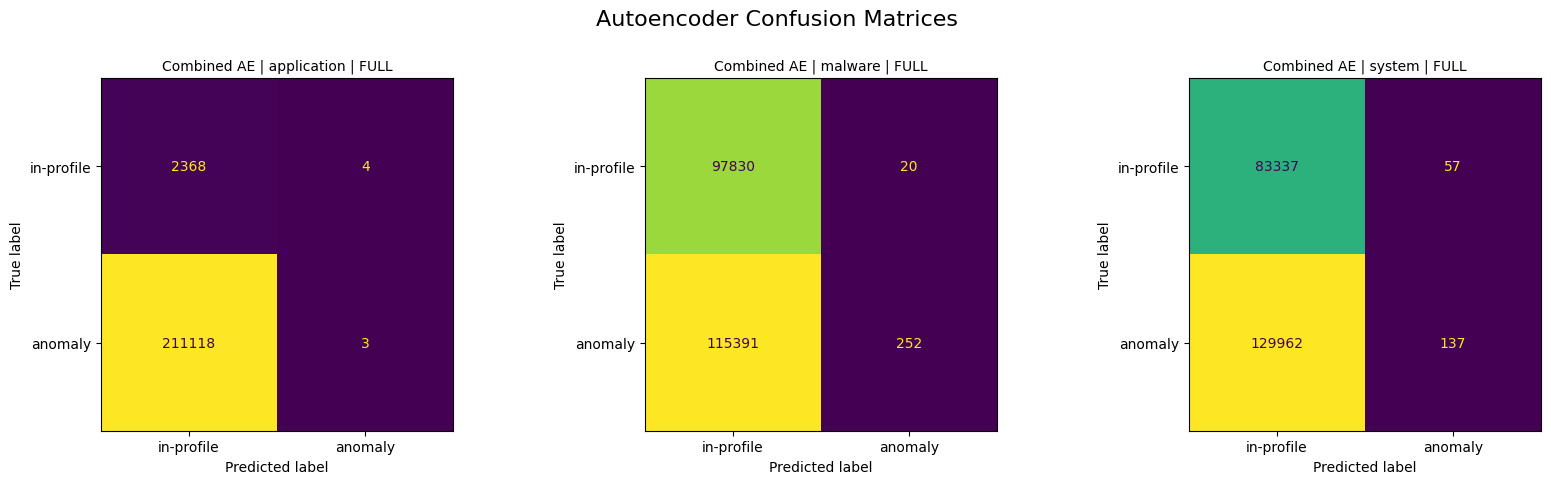

In [3]:
nrows = math.ceil(len(results) / ncols)
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5.5 * ncols, 4.8 * nrows))

if hasattr(axes, "ravel"):
    axes = axes.ravel()
else:
    axes = [axes]

value_format = ".2f" if normalize is not None else "d"

for ax, result in zip(axes, results):
    disp = ConfusionMatrixDisplay(
        confusion_matrix=result["ConfusionMatrix"],
        display_labels=["in-profile", "anomaly"],
    )
    disp.plot(ax=ax, colorbar=False, values_format=value_format)
    ax.set_title(result["Title"], fontsize=10)

for ax in axes[len(results):]:
    ax.axis("off")

title_suffix = " (normalized)" if normalize is not None else ""
fig.suptitle(f"Autoencoder Confusion Matrices{title_suffix}", fontsize=16, y=1.0)
plt.tight_layout()

if save_figure:
    figure_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(figure_path, dpi=200, bbox_inches="tight")
    print(f"Saved figure to {figure_path.resolve()}")

plt.show()


## Category Breakdown

For CSV files that include `original_category`, the figures below show the main confusion matrix together with one confusion matrix per original category subset.


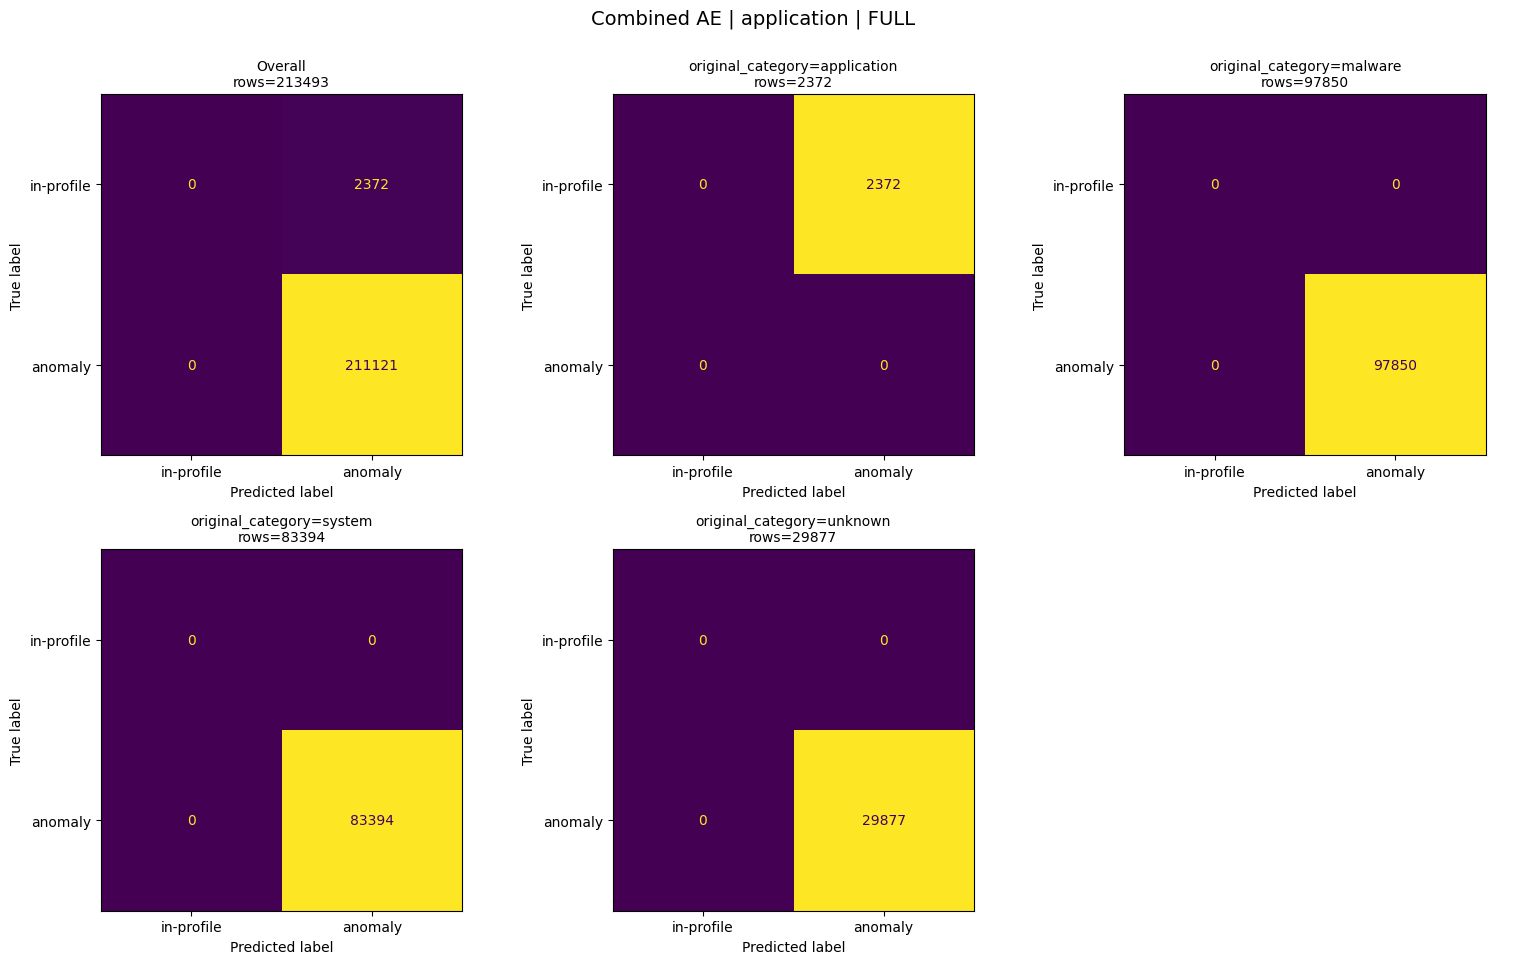

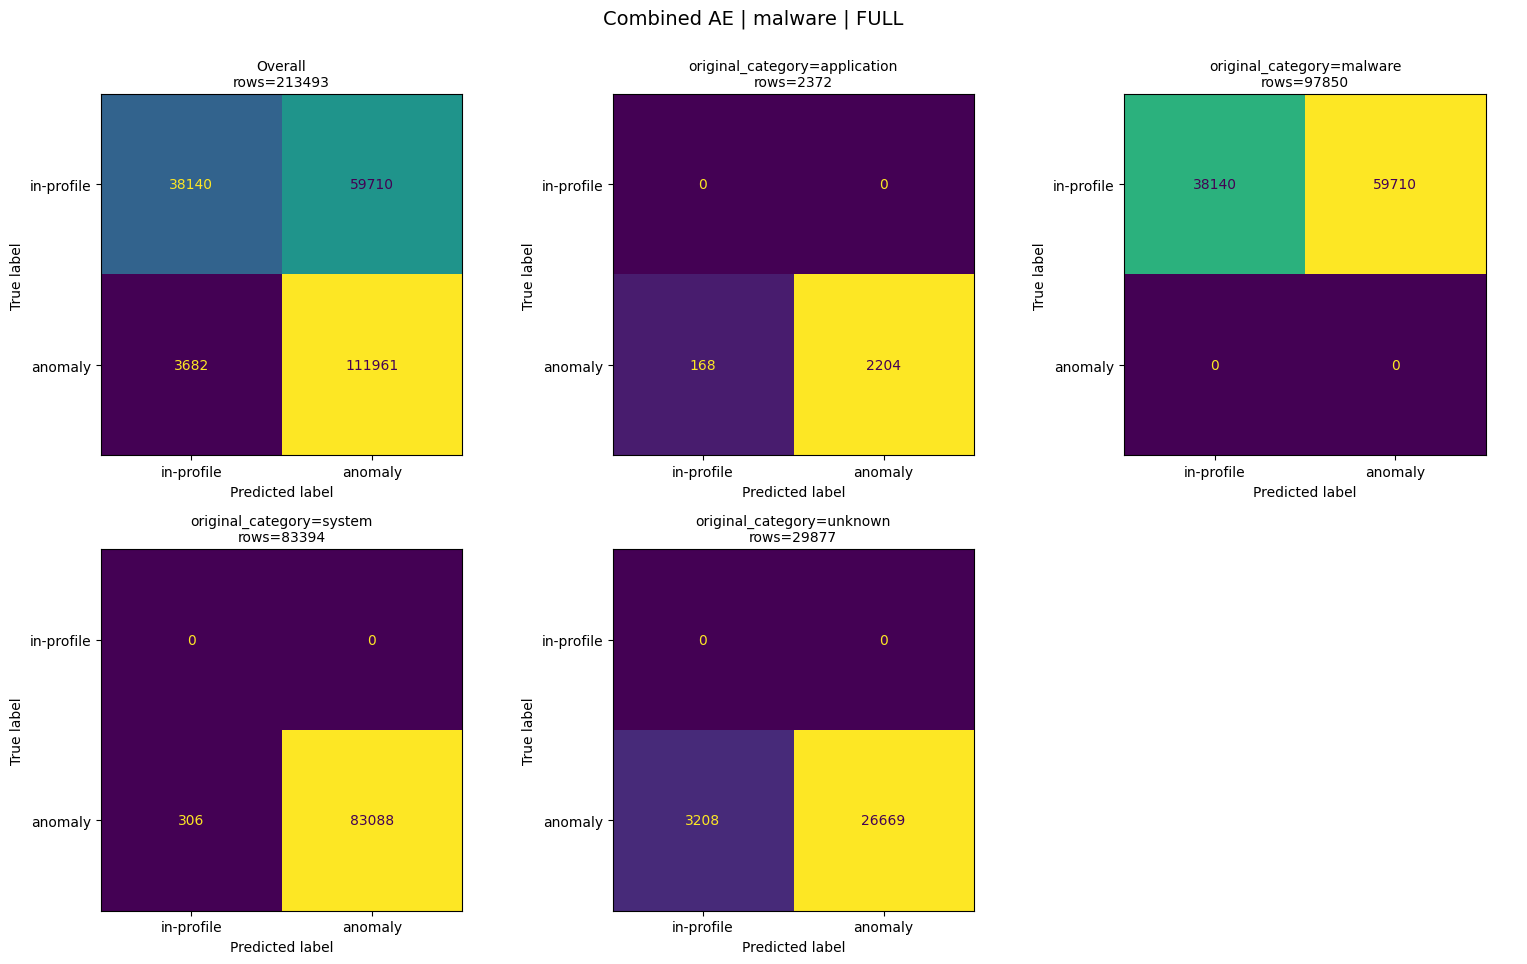

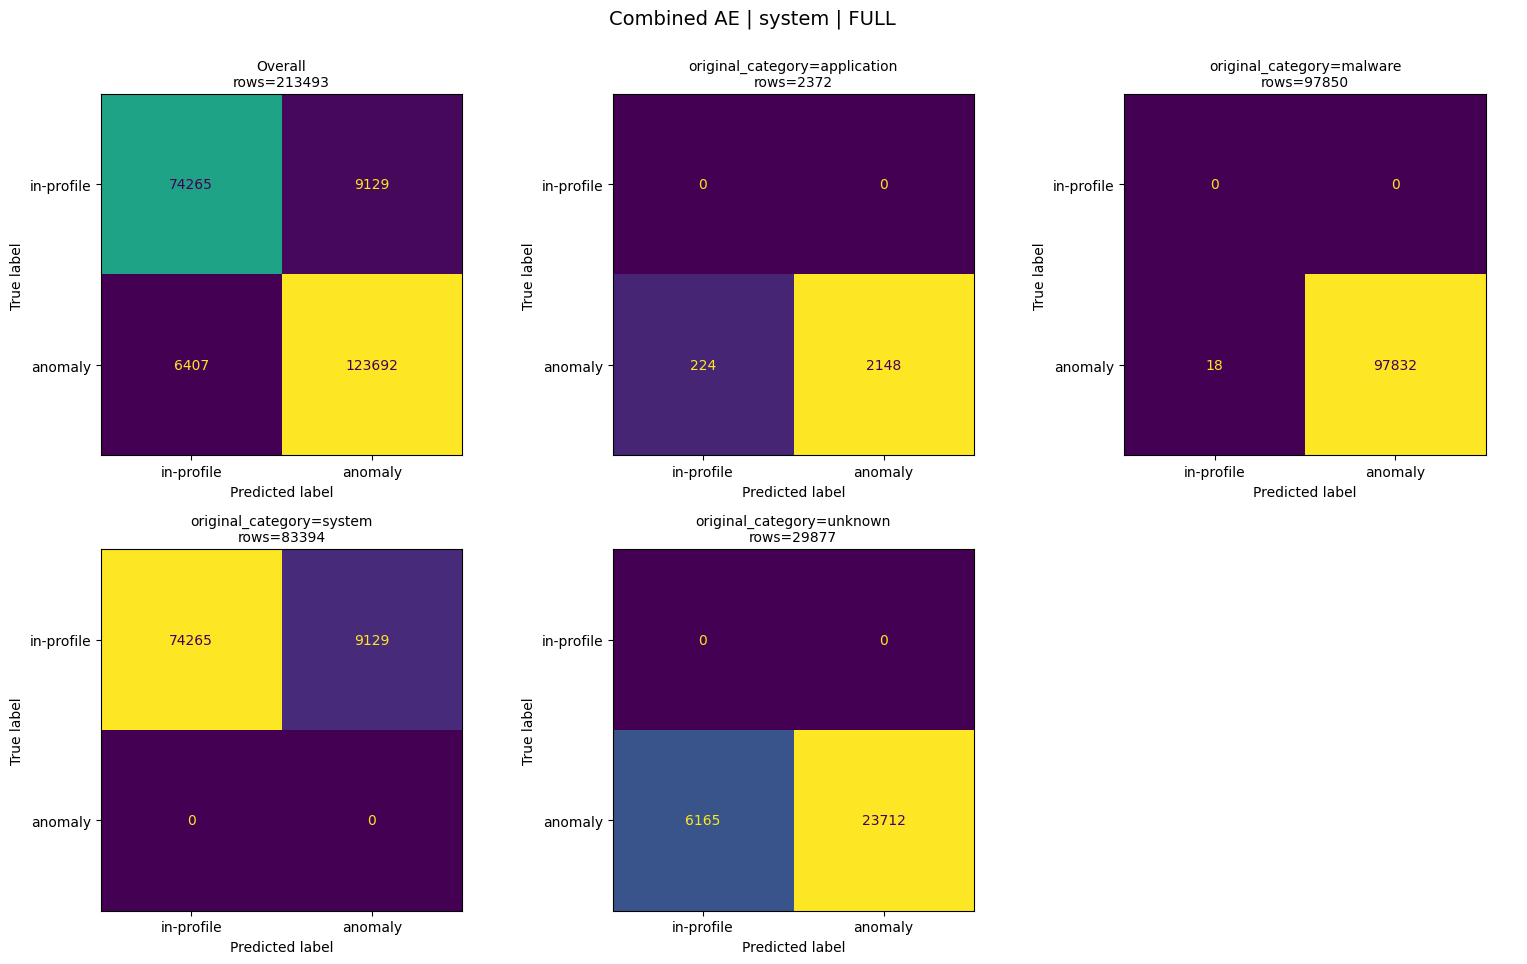

In [4]:
if show_category_breakdown:
    category_results = [result for result in results if result["CategoryMatrices"]]

    if not category_results:
        print("No CSV files with original_category were found. Rerun the generating notebook if you need category-level confusion matrices.")
    else:
        value_format = ".2f" if normalize is not None else "d"

        for result in category_results:
            categories = sorted(result["CategoryMatrices"])
            panels = [("Overall", result["ConfusionMatrix"], result["Rows"])] + [
                (
                    f"original_category={category}",
                    result["CategoryMatrices"][category]["ConfusionMatrix"],
                    result["CategoryMatrices"][category]["Rows"],
                )
                for category in categories
            ]

            panel_ncols = min(category_ncols, len(panels))
            panel_nrows = math.ceil(len(panels) / panel_ncols)
            fig, axes = plt.subplots(
                nrows=panel_nrows,
                ncols=panel_ncols,
                figsize=(5.2 * panel_ncols, 4.8 * panel_nrows),
            )

            if hasattr(axes, "ravel"):
                axes = axes.ravel()
            else:
                axes = [axes]

            for ax, (panel_title, panel_cm, panel_rows) in zip(axes, panels):
                disp = ConfusionMatrixDisplay(
                    confusion_matrix=panel_cm,
                    display_labels=["in-profile", "anomaly"],
                )
                disp.plot(ax=ax, colorbar=False, values_format=value_format)
                ax.set_title(f"{panel_title}\nrows={panel_rows}", fontsize=10)

            for ax in axes[len(panels):]:
                ax.axis("off")

            title_suffix = " (normalized)" if normalize is not None else ""
            fig.suptitle(f"{result['Title']}{title_suffix}", fontsize=14, y=1.0)
            plt.tight_layout()
            plt.show()
